In [1]:
!pip install torch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
#ハイパーパラメータ
input_dim = 784 #MNIST画像は28*28=784
hidden_dim = 200
latent_dim = 20
epochs = 30
learning_rate = 3e-4
batch_size = 32

In [3]:
class Encoder(nn.Module): #潜在変数zをサンプリングするためのmuとsigmaを出力
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super().__init__()
    self.linear = nn.Linear(input_dim, hidden_dim)
    self.linear_mu = nn.Linear(hidden_dim, latent_dim)
    self.linear_logvar = nn.Linear(hidden_dim, latent_dim)

  def forward(self, x):
    h = self.linear(x)
    h = F.relu(h)
    mu = self.linear_mu(h)
    logvar = self.linear_logvar(h)
    sigma = torch.exp(0.5 * logvar)
    return mu, sigma


class Decoder(nn.Module): #潜在変数zから元の入力を再構成
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super().__init__()
    self.linear1 = nn.Linear(latent_dim, hidden_dim)
    self.linear2 = nn.Linear(hidden_dim, output_dim)

  def forward(self, z):
    h = self.linear1(z)
    h = F.relu(h)
    h = self.linear2(h)
    x_hat = F.sigmoid(h)
    return x_hat

In [4]:
def reparameterize(mu, sigma): #zのサンプリングを変数変換トリックで実行
  eps = torch.randn_like(sigma)
  z = mu + eps * sigma
  return z


class VAE(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super().__init__()
    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
    self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

  def get_loss(self, x): #ELBOによる最適化
    mu, sigma = self.encoder(x)
    z = reparameterize(mu, sigma)
    x_hat = self.decoder(z)

    batch_size = len(x)
    L1 = F.mse_loss(x_hat, x, reduction="sum")
    L2 = - torch.sum(1 + torch.log(sigma ** 2) - mu ** 2 - sigma ** 2)
    return (L1 + L2) / batch_size

In [5]:
#MNISTでの学習
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(torch.flatten)
])

dataset = datasets.MNIST(
    root = "./data",
    train = True,
    download = True,
    transform = transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = True
)

model = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
losses = []

for epoch in range(epochs):
  loss_sum = 0.0
  count = 0

  for x, label in dataloader:
    optimizer.zero_grad()
    loss = model.get_loss(x)
    loss.backward()
    optimizer.step()

    loss_sum += loss.item()
    count += 1

  loss_avg = loss_sum / count
  losses.append(loss_avg)
  print(loss_avg)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.78MB/s]


53.941374251302086
44.860978236897786
43.04908763224284
41.94600564371745
41.23600500488281
40.774966927083334
40.451142541503906
40.18634475097656
39.96960375569662
39.823269014485675
39.701836450195316
39.57613846842448
39.47568986816406
39.3588396870931
39.32440393168132
39.22954165445964
39.15100006917318
39.063839788818356
39.00880639851888
38.93129889729818
38.87309006347656
38.84208557535807
38.773055780029296
38.75448254903158
38.71735889078776
38.64356210734049
38.62328657836914
38.60243915405273
38.540077164713544
38.542974444580075


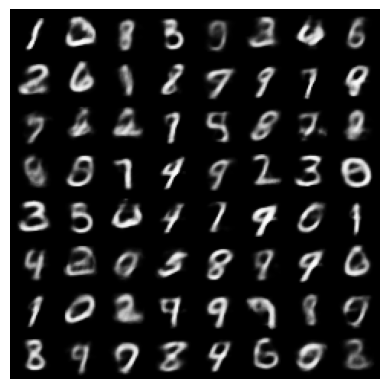

In [6]:
#新しい画像の生成
with torch.no_grad():
  sample_size = 64
  z = torch.randn(sample_size, latent_dim)
  x = model.decoder(z)
  generated_images = x.view(sample_size, 1, 28, 28)

grid_img = torchvision.utils.make_grid(
    generated_images,
    nrow = 8,
    padding = 2,
    normalize = True
)

plt.imshow(grid_img.permute(1,2,0))
plt.axis("off")
plt.show()